In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import wandb
import seaborn as sns

In [3]:
api = wandb.Api()
runs = api.runs("erpl/eedx")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/erwan/.netrc.


In [20]:
dfs = []
keys = ["angular_speed (avg)", "speed (avg)", "nb_neurons (avg)"]
for run in runs:
    if run.summary["_step"] < 2_000: continue
    df = run.history(keys=keys)
    df["condition"] = run.config["ft-1"]["dmin"]
    dfs.append(df)
df = pd.concat(dfs)

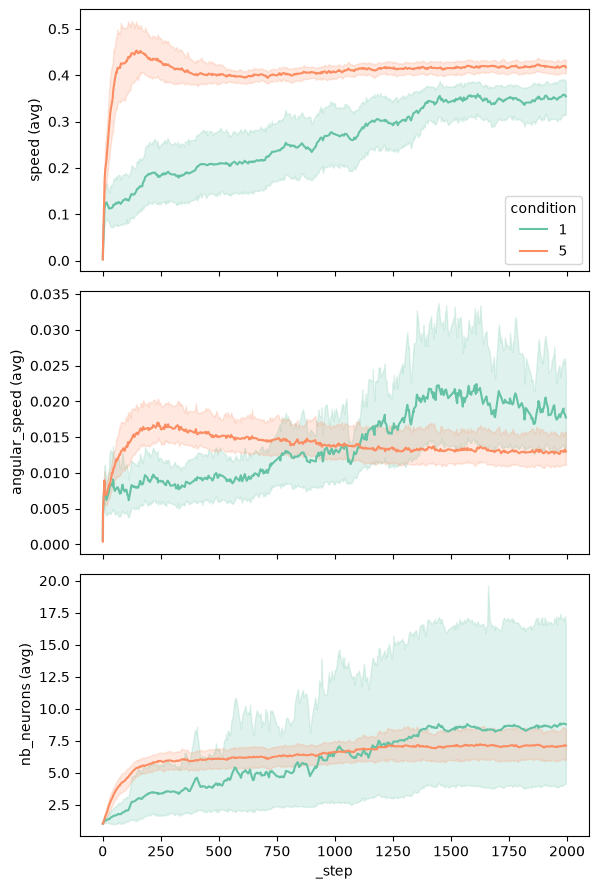

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(9, 9), sharex=True, width_ratios=[0.7,0.3])

sns.lineplot(df, x="_step", y="speed (avg)", hue="condition", palette="Set2", ax=ax[0,0])
sns.kdeplot(df, y="speed (avg)", hue="condition", palette="Set2", ax=ax[0,1])

sns.lineplot(df, x="_step", y="angular_speed (avg)", hue="condition", palette="Set2", legend=False, ax=ax[1,0])
sns.kdeplot(df, y="angular_speed (avg)", hue="condition", palette="Set2", ax=ax[1,1])

sns.lineplot(df, x="_step", y="nb_neurons (avg)", hue="condition", palette="Set2", legend=False, ax=ax[2,0])
sns.kdeplot(df, y="nb_neurons (avg)", hue="condition", palette="Set2", ax=ax[2,1])

fig.tight_layout()
plt.show()

_IncompleteInputError: incomplete input (3624708617.py, line 1)